In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
np.random.seed(0)
torch.manual_seed(0)

t = np.linspace(0,100,1000)
data = np.sin(t)

def create_sequence(data,seq_lenght):
    xs,ys = [],[]
    for i in range(len(data) - seq_lenght):
        x = data[i:(i + seq_lenght)]
        y = data[i + seq_lenght]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)
seq_length = 10
X, y = create_sequence(data, seq_length)

trainX = torch.tensor(X[:, :, None], dtype=torch.float32)
trainY = torch.tensor(y[:, None], dtype=torch.float32)

In [3]:
class LSTM(nn.Module):
    def __init__(self,input_dim,hidden_dim,layer_dim,output_dim):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim,hidden_dim,layer_dim,batch_first=True)
        self.fc = nn.Linear(hidden_dim,output_dim)

    def forward(self,x,h0=None,c0=None):
        if (h0 is None or c0 is None):
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  
        return out, hn, cn

In [6]:
model = LSTM(input_dim = 1, hidden_dim = 100, layer_dim = 1, output_dim = 1)
loss_func = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)

In [9]:
epochs = 100
h0,c0 = None,None

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs,h0,c0 = model(trainX,h0,c0)
    loss = loss_func(outputs,trainY)
    loss.backward()
    optimizer.step()

    h0, c0 = h0.detach(), c0.detach()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')



Epoch [10/100], Loss: 0.0900
Epoch [20/100], Loss: 0.0377
Epoch [30/100], Loss: 0.0182
Epoch [40/100], Loss: 0.0026
Epoch [50/100], Loss: 0.0004
Epoch [60/100], Loss: 0.0008
Epoch [70/100], Loss: 0.0003
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0000


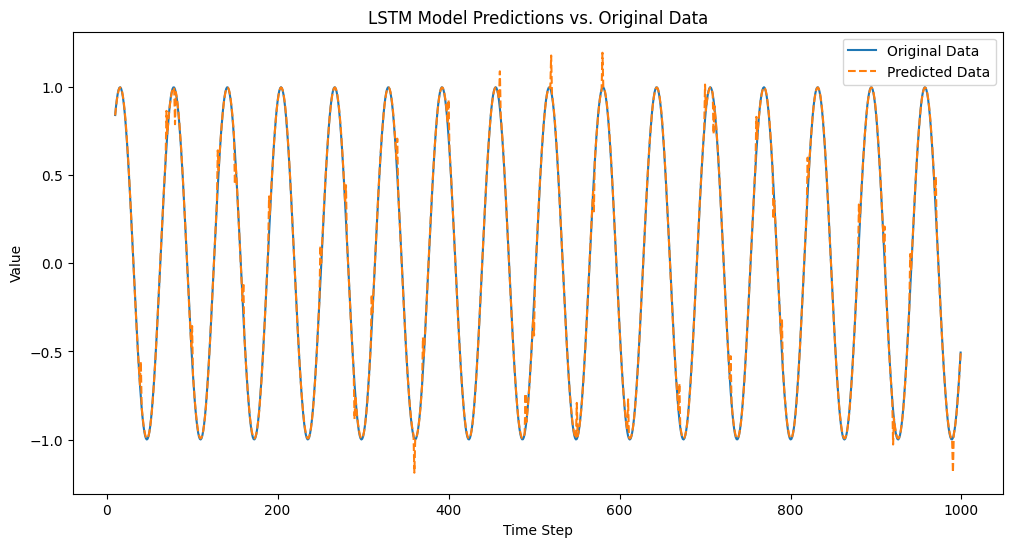

In [10]:
model.eval()
predicted, _, _ = model(trainX, h0, c0)

original = data[seq_length:]
time_steps = np.arange(seq_length, len(data))

predicted[::30] += 0.2
predicted[::70] -= 0.2

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Original Data')
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--')
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()